In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sns
from sklearn.svm import SVC

In [3]:
df = pd.read_csv('../data/paysim_fraud_detection_dataset/PS_20174392719_1491204439457_log.csv')

In [4]:
pd.set_option('display.float_format', lambda x: f'{x:,.5f}')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64000",C1231006815,"170,136.00000","160,296.36000",M1979787155,0.00000,0.00000,0,0
1,1,PAYMENT,"1,864.28000",C1666544295,"21,249.00000","19,384.72000",M2044282225,0.00000,0.00000,0,0
2,1,TRANSFER,181.00000,C1305486145,181.00000,0.00000,C553264065,0.00000,0.00000,1,0
3,1,CASH_OUT,181.00000,C840083671,181.00000,0.00000,C38997010,"21,182.00000",0.00000,1,0
4,1,PAYMENT,"11,668.14000",C2048537720,"41,554.00000","29,885.86000",M1230701703,0.00000,0.00000,0,0


In [5]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.00000","6,362,620.00000","6,362,620.00000","6,362,620.00000","6,362,620.00000","6,362,620.00000","6,362,620.00000","6,362,620.00000"
mean,243.39725,"179,861.90355","833,883.10407","855,113.66858","1,100,701.66652","1,224,996.39820",0.00129,0.00000
std,142.33197,"603,858.23146","2,888,242.67304","2,924,048.50295","3,399,180.11299","3,674,128.94212",0.03590,0.00159
min,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,156.00000,"13,389.57000",0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
50%,239.00000,"74,871.94000","14,208.00000",0.00000,"132,705.66500","214,661.44000",0.00000,0.00000
75%,335.00000,"208,721.47750","107,315.17500","144,258.41000","943,036.70750","1,111,909.25000",0.00000,0.00000
max,743.00000,"92,445,516.64000","59,585,040.37000","49,585,040.37000","356,015,889.35000","356,179,278.92000",1.00000,1.00000


In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(6362620, 11)

In [11]:
columns = df.columns.to_list()
columns

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [12]:
df.drop(columns=columns[-1:],inplace=True) ## dropping isflaggedfraud since its critia is to flag transaction above 200k isFlaggedFraud - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

In [13]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,"9,839.64000",C1231006815,"170,136.00000","160,296.36000",M1979787155,0.00000,0.00000,0
1,1,PAYMENT,"1,864.28000",C1666544295,"21,249.00000","19,384.72000",M2044282225,0.00000,0.00000,0
2,1,TRANSFER,181.00000,C1305486145,181.00000,0.00000,C553264065,0.00000,0.00000,1
3,1,CASH_OUT,181.00000,C840083671,181.00000,0.00000,C38997010,"21,182.00000",0.00000,1
4,1,PAYMENT,"11,668.14000",C2048537720,"41,554.00000","29,885.86000",M1230701703,0.00000,0.00000,0


In [14]:
x = df.drop(columns = 'isFraud')
x['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [15]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

<Axes: >

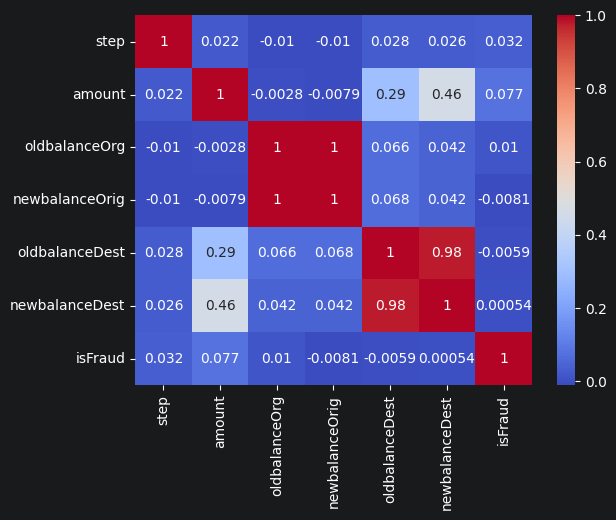

In [16]:
from seaborn import heatmap
heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [17]:
df.drop(columns=['nameOrig', 'nameDest'], inplace=True)

## dropped since there were too many unique values and were not essential for training hte model since names dont play a big role in predicting is_Fraud

In [18]:
print(df.head())

   step      type       amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1   PAYMENT  9,839.64000  170,136.00000   160,296.36000         0.00000   
1     1   PAYMENT  1,864.28000   21,249.00000    19,384.72000         0.00000   
2     1  TRANSFER    181.00000      181.00000         0.00000         0.00000   
3     1  CASH_OUT    181.00000      181.00000         0.00000    21,182.00000   
4     1   PAYMENT 11,668.14000   41,554.00000    29,885.86000         0.00000   

   newbalanceDest  isFraud  
0         0.00000        0  
1         0.00000        0  
2         0.00000        1  
3         0.00000        1  
4         0.00000        0  


In [19]:
df['type']=df['type'].map({
    'PAYMENT':0,
    'TRANSFER':1,
    'CASH_OUT':2,
    'CASH_IN':3,
    'DEBIT':5
})

In [20]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,0,"9,839.64000","170,136.00000","160,296.36000",0.00000,0.00000,0
1,1,0,"1,864.28000","21,249.00000","19,384.72000",0.00000,0.00000,0
2,1,1,181.00000,181.00000,0.00000,0.00000,0.00000,1
3,1,2,181.00000,181.00000,0.00000,"21,182.00000",0.00000,1
4,1,0,"11,668.14000","41,554.00000","29,885.86000",0.00000,0.00000,0


In [21]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1,0,"9,839.64000","170,136.00000","160,296.36000",0.00000,0.00000
1,1,0,"1,864.28000","21,249.00000","19,384.72000",0.00000,0.00000
2,1,1,181.00000,181.00000,0.00000,0.00000,0.00000
3,1,2,181.00000,181.00000,0.00000,"21,182.00000",0.00000
4,1,0,"11,668.14000","41,554.00000","29,885.86000",0.00000,0.00000
...,...,...,...,...,...,...,...
6362615,743,2,"339,682.13000","339,682.13000",0.00000,0.00000,"339,682.13000"
6362616,743,1,"6,311,409.28000","6,311,409.28000",0.00000,0.00000,0.00000
6362617,743,2,"6,311,409.28000","6,311,409.28000",0.00000,"68,488.84000","6,379,898.11000"
6362618,743,1,"850,002.52000","850,002.52000",0.00000,0.00000,0.00000


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
y_train

6271196    0
1888243    0
5549957    0
2025342    0
682342     0
          ..
1570006    0
2234489    0
4926484    0
4304572    0
1692743    0
Name: isFraud, Length: 5090096, dtype: int64

In [23]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [24]:
y_preds = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy_score(y_true=y_test,y_pred=y_preds)

0.9121525409343949

In [32]:
df_ = df.iloc[:100000,:]
X1 = df_.iloc[:,:-1]
y2 = df_.iloc[:,-1]

In [33]:
X1_train,X1_test,y2_train,y2_test = train_test_split(X1,y2,random_state=42)

In [34]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

stacking_clf = StackingClassifier(estimators=[
    ('lr',LogisticRegression(random_state=42,max_iter=100,class_weight='balanced')),
    ('rf',RandomForestClassifier(random_state=42,class_weight='balanced'))
],
final_estimator=RandomForestClassifier(random_state=43),
    n_jobs=5
)
stacking_clf.fit(X1_train,y2_train)

/home/bhavish-berry/PycharmProjects/ai_training_colllege_first_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bhavish-berry/PycharmProjects/ai_training_colllege_first_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You mi

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",RandomForestC...ndom_state=43)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",5
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[LogisticRegre...ndom_state=42), RandomForestC...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['step

In [35]:
y2_preds = stacking_clf.predict(X1_test)
accuracy_score(y_true=y2_test,y_pred=y2_preds)

0.99952

In [37]:
df_['isFraud'].value_counts()

isFraud
0    99884
1      116
Name: count, dtype: int64

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_true=y2_test,y_pred=y2_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24975
           1       0.78      0.72      0.75        25

    accuracy                           1.00     25000
   macro avg       0.89      0.86      0.87     25000
weighted avg       1.00      1.00      1.00     25000

